<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Device: cpu

================ STEP 1: DATA LOADING ================
train.csv → (160000, 2)
test.csv → (160000, 2)
phiusiil.csv → (235795, 2)

================ STEP 2: LABEL DISTRIBUTION ================


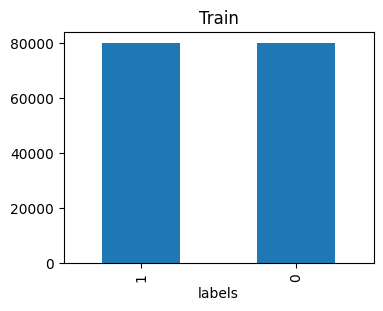

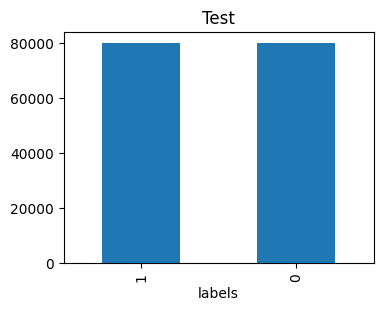

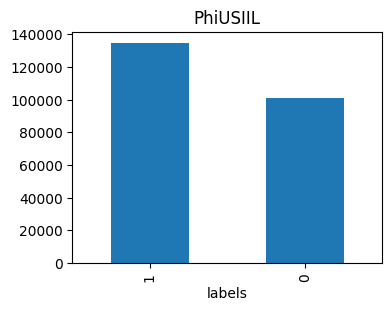


================ STEP 3: LEXICAL FEATURES ================

================ STEP 4: CHAR N-GRAM TF-IDF ================

================ STEP 5: FEATURE FUSION ================

================ STEP 6: ONLINE ML CLASSIFIER ================

================ STEP 7: ISOLATION FOREST ================


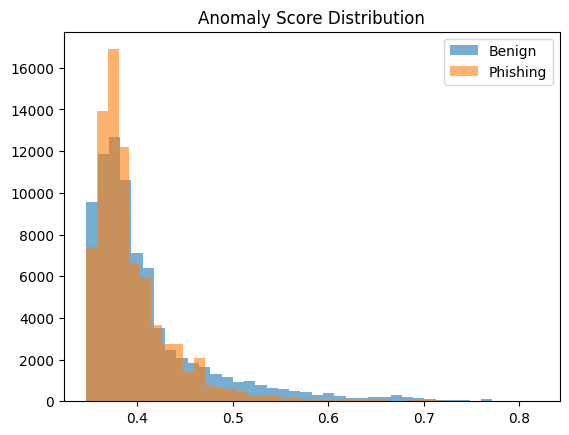


================ STEP 8: TINY TCN + ATTENTION ================
Epoch 1 done
Epoch 2 done
Epoch 3 done

================ STEP 9: SCORE FUSION ================

================ STEP 10: EVALUATION + GRAPHS ================


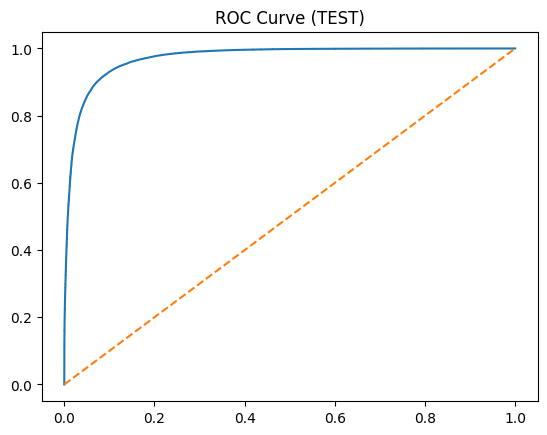

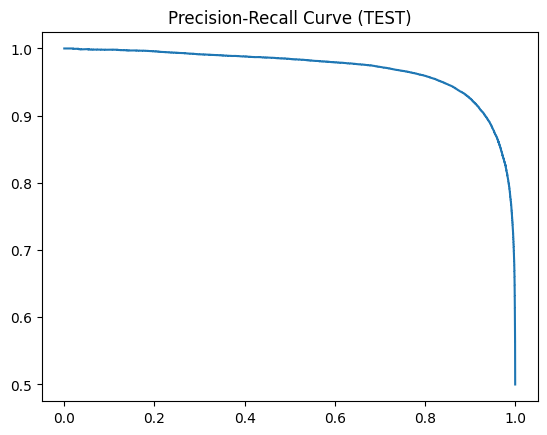

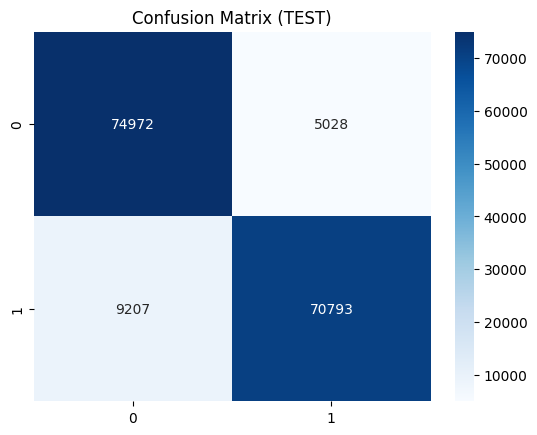

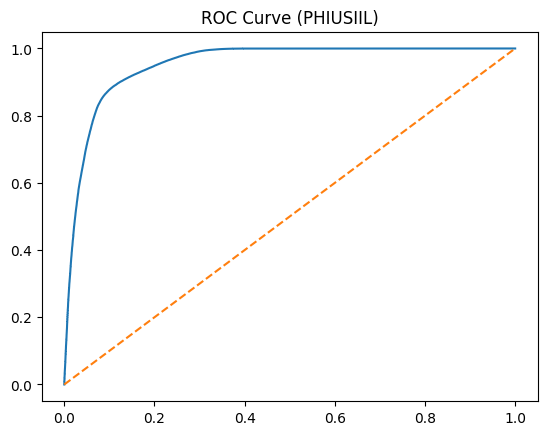

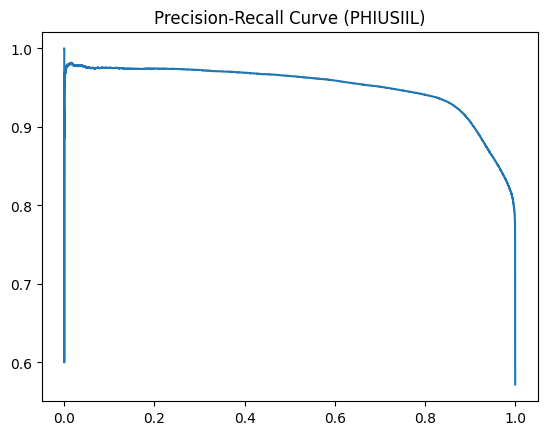

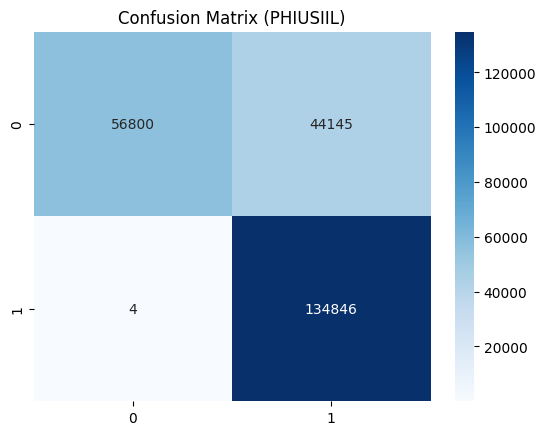


================ STEP 11: ATTENTION MAP ================


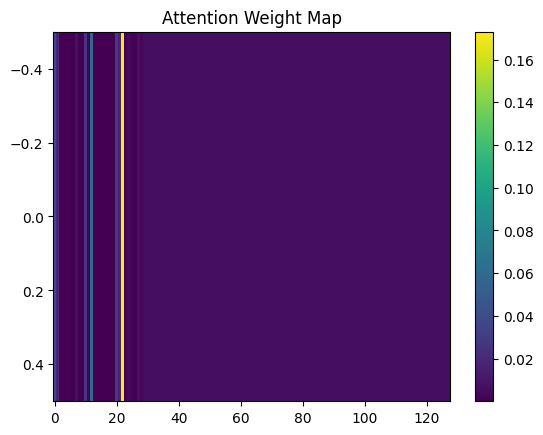


================ STEP 12: CONCEPT DRIFT ================


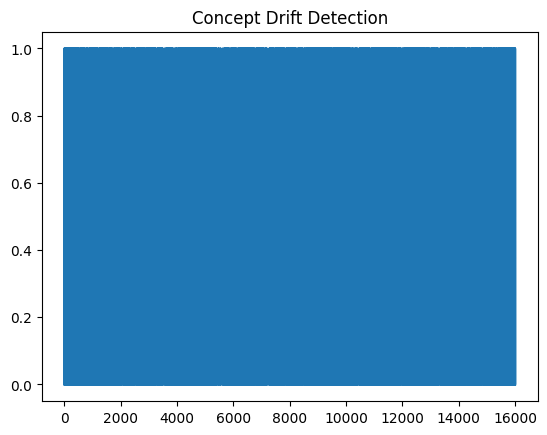


================ PIPELINE COMPLETED SUCCESSFULLY ================


In [5]:
# ==========================================================
# FULL HYBRID PHISHING URL DETECTION SYSTEM
# WITH ALL REQUIRED VISUALIZATIONS
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc, confusion_matrix
)
from scipy.sparse import hstack

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✔ Device: {device}")

# ==========================================================
print("\n================ STEP 1: DATA LOADING ================")

BASE = "/content/drive/MyDrive/data"
TRAIN = os.path.join(BASE, "train.csv")
TEST  = os.path.join(BASE, "test.csv")
PHI   = os.path.join(BASE, "phiusiil.csv")

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)
    print(f"{os.path.basename(path)} → {df.shape}")
    return df

train_df = load_data(TRAIN)
test_df  = load_data(TEST)
phi_df   = load_data(PHI)

# ==========================================================
print("\n================ STEP 2: LABEL DISTRIBUTION ================")

for name, df in [("Train",train_df),("Test",test_df),("PhiUSIIL",phi_df)]:
    df.labels.value_counts().plot(kind="bar", figsize=(4,3), title=name)
    plt.show()

# ==========================================================
print("\n================ STEP 3: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

# ==========================================================
print("\n================ STEP 4: CHAR N-GRAM TF-IDF ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=5)
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

# ==========================================================
print("\n================ STEP 5: FEATURE FUSION ================")

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels

# ==========================================================
print("\n================ STEP 6: ONLINE ML CLASSIFIER ================")

clf = SGDClassifier(loss="log_loss")
clf.fit(X_train_ml, y_train)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

# ==========================================================
print("\n================ STEP 7: ISOLATION FOREST ================")

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_lex_train[y_train==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

plt.hist(a_test[y_test==0], bins=40, alpha=0.6, label="Benign")
plt.hist(a_test[y_test==1], bins=40, alpha=0.6, label="Phishing")
plt.legend(); plt.title("Anomaly Score Distribution"); plt.show()

# ==========================================================
print("\n================ STEP 8: TINY TCN + ATTENTION ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s=[char2idx.get(c,0) for c in str(u)[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,y_train),256,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,y_test),256)
phi_dl  =DataLoader(URLDS(phi_df.url,y_phi),256)

class TinyTCNAttn(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv=nn.Conv1d(64,64,3,padding=1)
        self.attn=nn.Linear(64,1)
        self.fc=nn.Linear(64,1)
    def forward(self,x,return_attn=False):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv(x)).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        out=self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()
        return (out,w) if return_attn else out

model=TinyTCNAttn(len(char2idx)).to(device)
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(3):
    for X,y in train_dl:
        X,y=X.to(device),y.to(device)
        opt.zero_grad()
        loss=lossf(model(X),y)
        loss.backward()
        opt.step()
    print(f"Epoch {e+1} done")

def dl_scores(dl):
    model.eval(); s=[]
    with torch.no_grad():
        for X,_ in dl:
            X=X.to(device)
            s.extend(torch.sigmoid(model(X)).cpu().numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 9: SCORE FUSION ================")

α=0.6
S_test = α*p_ml_test + (1-α)*p_dl_test*(1-a_test/np.max(a_test))
S_phi  = α*p_ml_phi  + (1-α)*p_dl_phi *(1-a_phi/np.max(a_phi))

yhat_test=(S_test>0.5).astype(int)
yhat_phi =(S_phi>0.5).astype(int)

# ==========================================================
print("\n================ STEP 10: EVALUATION + GRAPHS ================")

def plots(y, s, name):
    fpr,tpr,_=roc_curve(y,s)
    p,r,_=precision_recall_curve(y,s)

    plt.plot(fpr,tpr,label="ROC")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve ({name})"); plt.show()

    plt.plot(r,p)
    plt.title(f"Precision-Recall Curve ({name})"); plt.show()

    cm=confusion_matrix(y,(s>0.5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(f"Confusion Matrix ({name})"); plt.show()

plots(y_test,S_test,"TEST")
plots(y_phi,S_phi,"PHIUSIIL")

# ==========================================================
print("\n================ STEP 11: ATTENTION MAP ================")

model.eval()
sample,_=next(iter(test_dl))
sample=sample[:1].to(device)
_,attn=model(sample,return_attn=True)
plt.imshow(attn.cpu().detach().numpy(),aspect="auto",cmap="viridis")
plt.colorbar(); plt.title("Attention Weight Map"); plt.show()

# ==========================================================
print("\n================ STEP 12: CONCEPT DRIFT ================")

class PageHinkley:
    def __init__(self,delta=0.005,lam=50):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()
losses=[]; drifts=[]
for i in range(0,len(y_test),10):
    err=int(yhat_test[i]!=y_test.iloc[i])
    losses.append(err)
    if ph.update(err):
        drifts.append(i)

plt.plot(losses);
for d in drifts: plt.axvline(d,color="red",ls="--")
plt.title("Concept Drift Detection"); plt.show()

print("\n================ PIPELINE COMPLETED SUCCESSFULLY ================")
